In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/felipe_cds/carla-bc-bev")

In [79]:
from expert_dataset_def.expert_dataset import ExpertDataset
import torch as th
import tqdm
batch_size = 8
val_loader = th.utils.data.DataLoader(
        ExpertDataset(
            'expert-data',
            routes=[0,1],
            n_eps=1,
            unet=True,
            sizes=(480,224,200)
            
        ),
        batch_size=batch_size,
        shuffle=False,
    )

In [75]:
from bev_generation.cvt_3ch import CVT_3chL1Generator
from bev_generation.cvt_6ch import CVT_6chVanilla
from bev_generation.unet import Unet_BEVGenerator

# bev_generator = CVT_3chL1Generator(device='cuda')
bev_generator = CVT_6chVanilla(device='cuda')
# bev_generator = Unet_BEVGenerator(device='cuda')




Loaded pretrained weights for efficientnet-b4


In [78]:
import os
import torch
import torchvision
import tqdm

# Índices globais das imagens que deseja salvar (0-based)
target_indices = [400, 700, 900, 1050]
save_dir = '/home/felipe_cds/carla-bc-bev/eval/cvt_6ch'
os.makedirs(save_dir, exist_ok=True)


with torch.no_grad():
    for batch_idx, expert_batch in enumerate(tqdm.tqdm(val_loader, desc='Saving BEVs')):
        fake_bev = bev_generator.infer(expert_batch[0])  # (B, C, H, W)
        real_bev = expert_batch[0]['bev']                # (B, C, H, W)
        
        batch_size = fake_bev.shape[0]
        
        for i in range(batch_size):
            global_idx = batch_idx * batch_size + i
            
            if global_idx in target_indices:
                # 1. Converte para float e move para CPU (evita o RuntimeError)
                fake_img = fake_bev[i].float().cpu()
                real_img = real_bev[i].float().cpu()
                
                # 2. Salva (se os valores já estão em [0, 1], remova normalize=True)
                torchvision.utils.save_image(fake_img, f'{save_dir}/fake_{global_idx}.png')
                torchvision.utils.save_image(real_img, f'{save_dir}/real_{global_idx}.png')
                
                target_indices.remove(global_idx)
                
            if not target_indices:
                break
        if not target_indices:
            break

print(f"✅ {len(os.listdir(save_dir))//2} imagens salvas em {save_dir}")

Saving BEVs:   0%|          | 0/414 [00:00<?, ?it/s]

Saving BEVs:   0%|          | 0/414 [00:00<?, ?it/s]


RuntimeError: The size of tensor a (30) must match the size of tensor b (14) at non-singleton dimension 3

In [58]:
import torch
import torch.nn.functional as F
import tqdm
import csv

csv_path = '/home/felipe_cds/carla-bc-bev/eval/cvt_6ch_iou_results.csv'

# 1. Cria o CSV com cabeçalho
with open(csv_path, 'w', newline='') as f:
    csv.writer(f).writerow(['batch_idx', 'sample_idx', 'iou_ch0', 'iou_ch1', 'iou_ch2', 'mean_iou'])


rows_to_save = []

with torch.no_grad():
    for batch_idx, expert_batch in enumerate(tqdm.tqdm(val_loader, desc='Batches:')):
        # Predição e Ground Truth
        if 1500 in expert_batch[0]['item_idx']:
            break
        fake_bev = bev_generator.infer(expert_batch[0])  # (B, 3, 192, 192)
        real_bev = expert_batch[0]['bev']                # (B, 3, 256, 256)

        

        # Garante que são tensores
        if not isinstance(fake_bev, torch.Tensor): fake_bev = torch.as_tensor(fake_bev)
        if not isinstance(real_bev, torch.Tensor): real_bev = torch.as_tensor(real_bev)

        # 2. Redimensiona a BEV real para o tamanho da predita usando NEAREST
        H_pred, W_pred = fake_bev.shape[2], fake_bev.shape[3]
        real_bev_resized = F.interpolate(real_bev.float(), size=(H_pred, W_pred), mode='nearest')

        # 3. Binariza (considera > 0.5 como pertencente à classe)
        pred_bin = (fake_bev > 0.5).float().cpu()
        target_bin = (real_bev_resized > 0.5).float().cpu()

        # 4. Calcula IoU vetorizado para todo o batch e canais
        intersection = (pred_bin * target_bin).sum(dim=(2, 3))
        union = pred_bin.sum(dim=(2, 3)) + target_bin.sum(dim=(2, 3)) - intersection
        iou_batch = intersection / (union + 1e-7)  # shape: (B, 3)

        # 5. Prepara linhas para o CSV
        for i in range(iou_batch.shape[0]):
            ious = iou_batch[i].cpu().tolist()
            mean_iou = sum(ious) / len(ious)
            rows_to_save.append([batch_idx, i] + ious + [mean_iou])

# 6. Salva tudo no CSV
with open(csv_path, 'a', newline='') as f:
    csv.writer(f).writerows(rows_to_save)

print(f"✅ IoU calculado e salvo em {csv_path}")

Batches::   0%|          | 0/414 [00:00<?, ?it/s]

Batches::  45%|████▌     | 187/414 [00:56<01:08,  3.32it/s]

✅ IoU calculado e salvo em /home/felipe_cds/carla-bc-bev/eval/cvt_6ch_iou_results.csv


✅ Carregado: CVT 3 canais (1440 amostras)
✅ Carregado: CVT ruido (1440 amostras)
✅ Carregado: UNet Baseline (1440 amostras)


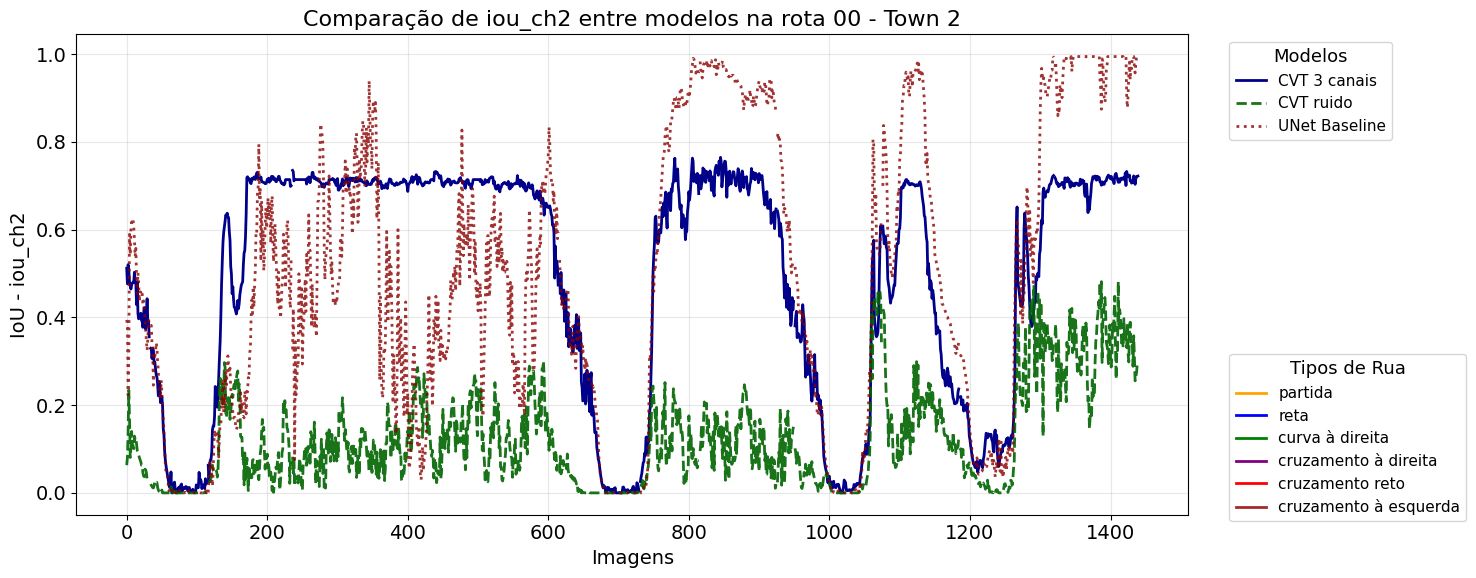

'\nresumo = []\nfor model_name, df in dataframes.items():\n    for tipo_rua, intervalos in pedacos.items():\n        lista_intervalos = [intervalos] if isinstance(intervalos, tuple) else intervalos\n        indices = []\n        for inicio, fim in lista_intervalos:\n            indices.extend(range(inicio, fim))\n        if indices:\n            media_iou = df.iloc[indices][METRIC_COL].mean()\n            resumo.append({\'Modelo\': model_name, \'Segmento\': tipo_rua, METRIC_COL: media_iou})\n\npd.DataFrame(resumo).to_csv(eval_folder / \'iou_resumo_por_segmento.csv\', index=False)\nprint("📊 Resumo salvo em iou_resumo_por_segmento.csv")\n'

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ================= CONFIGURAÇÃO =================
# Pasta com os CSVs de avaliação
eval_folder = Path('/home/felipe_cds/carla-bc-bev/eval')

# Lista dos 3 arquivos CSV (ajuste os nomes conforme necessário)
csv_files = {
    'CVT 3 canais': eval_folder / 'cvt_3ch_iou_results.csv',
    'CVT ruido': eval_folder / 'cvt_6ch_iou_results.csv',
    'UNet Baseline': eval_folder / 'unet_iou_results.csv',
}

# Coluna a ser plotada: 'mean_iou' ou 'iou_ch0', 'iou_ch1', etc.
METRIC_COL = 'iou_ch2'

# Intervalos de imagens por tipo de segmento de rua
pedacos = {
    'partida': (0, 33),
    'reta': [(34, 115), (236, 615), (731, 815), (926, 950), (1076, 1185), (1310, 1320)],
    'curva à direita': [(116, 235), (616, 730)],
    'cruzamento à direita': (816, 925),
    'cruzamento reto': (951, 1075),
    'cruzamento à esquerda': [(1186, 1309), (1321, 1440)]
}

# Cores para cada tipo de rua (mantidas do original)
cores_rua = {
    'partida': 'orange',
    'reta': 'blue',
    'curva à direita': 'green',
    'cruzamento à direita': 'purple',
    'cruzamento reto': 'red',
    'cruzamento à esquerda': 'brown'
}

# Cores e estilos para os 3 modelos
configs_modelos = {
    'CVT 3 canais': {'color': 'darkblue', 'linestyle': '-', 'alpha': 1.0},
    'CVT ruido': {'color': 'darkgreen', 'linestyle': '--', 'alpha': 0.9},
    'UNet Baseline': {'color': 'darkred', 'linestyle': ':', 'alpha': 0.8},
}

# ================= FUNÇÕES AUXILIARES =================
def load_and_prepare_csv(csv_path, max_samples=1440):
    """Carrega CSV, cria índice contínuo e limita ao número de amostras desejado."""
    df = pd.read_csv(csv_path)
    
    # Cria índice contínuo: Image_Index = batch_idx * batch_size + sample_idx
    # Assumindo batch_size=8 (ajuste se necessário)
    if 'Image_Index' not in df.columns:
        df['Image_Index'] = df['batch_idx'] * 8 + df['sample_idx']
    
    # Ordena e limita
    df = df.sort_values('Image_Index').iloc[:max_samples].reset_index(drop=True)
    return df

def plot_segment(df, color, linestyle, alpha, linewidth=2):
    """Plota um segmento do DataFrame com o estilo especificado."""
    plt.plot(df['Image_Index'], df[METRIC_COL], 
             color=color, linestyle=linestyle, 
             alpha=alpha, linewidth=linewidth)

# ================= PREPARAÇÃO DOS DADOS =================
plt.rcParams.update({'font.size': 14})

# Carrega e prepara os DataFrames de cada modelo
dataframes = {}
for name, path in csv_files.items():
    if path.exists():
        dataframes[name] = load_and_prepare_csv(path)
        print(f"✅ Carregado: {name} ({len(dataframes[name])} amostras)")
    else:
        print(f"⚠️ Arquivo não encontrado: {path}")

# ================= PLOTAGEM =================
plt.figure(figsize=(15, 6))

# Plota cada modelo, segmento por segmento
for model_name, df in dataframes.items():
    cfg = configs_modelos[model_name]
    for tipo_rua, intervalos in pedacos.items():
        # Converte para lista de tuplas para tratamento uniforme
        lista_intervalos = [intervalos] if isinstance(intervalos, tuple) else intervalos
        
        for inicio, fim in lista_intervalos:
            df_seg = df.iloc[inicio:fim]
            if len(df_seg) > 0:
                plot_segment(df_seg, cfg['color'], cfg['linestyle'], cfg['alpha'])

# ================= LEGENDAS =================
# Legenda dos tipos de rua
legend_rua = [Line2D([0], [0], color=c, lw=2, label=t) for t, c in cores_rua.items()]

# Legenda dos modelos
legend_modelos = [
    Line2D([0], [0], color=cfg['color'], lw=2, 
           linestyle=cfg['linestyle'], alpha=cfg['alpha'], label=name)
    for name, cfg in configs_modelos.items()
]

# ================= FORMATAÇÃO FINAL =================
plt.title(f'Comparação de {METRIC_COL} entre modelos na rota 00 - Town 2', fontsize=16)
plt.xlabel('Imagens', fontsize=14)
plt.ylabel('IoU' if METRIC_COL == 'mean_iou' else f'IoU - {METRIC_COL}', fontsize=14)
plt.grid(True, alpha=0.3)

# Adiciona as duas legendas (modelos + tipos de rua)
leg1 = plt.legend(handles=legend_modelos, loc='upper left', title="Modelos", 
                  bbox_to_anchor=(1.03, 1), fontsize=11, title_fontsize=13)
leg2 = plt.legend(handles=legend_rua, loc='upper left', title="Tipos de Rua", 
                  bbox_to_anchor=(1.03, 0.35), fontsize=11, title_fontsize=13)
plt.gca().add_artist(leg1)

plt.tight_layout()
plt.show()

# ================= OPCIONAL: SALVAR TABELA RESUMO =================
# Descomente para gerar um CSV com IoU médio por segmento e modelo
"""
resumo = []
for model_name, df in dataframes.items():
    for tipo_rua, intervalos in pedacos.items():
        lista_intervalos = [intervalos] if isinstance(intervalos, tuple) else intervalos
        indices = []
        for inicio, fim in lista_intervalos:
            indices.extend(range(inicio, fim))
        if indices:
            media_iou = df.iloc[indices][METRIC_COL].mean()
            resumo.append({'Modelo': model_name, 'Segmento': tipo_rua, METRIC_COL: media_iou})

pd.DataFrame(resumo).to_csv(eval_folder / 'iou_resumo_por_segmento.csv', index=False)
print("📊 Resumo salvo em iou_resumo_por_segmento.csv")
"""